# 01 — Exploratory Data Analysis

Confirm the seasonality assumptions that justify SARIMA over plain ARIMA, and document data quality.

Inputs: `data/raw/PJME_hourly.csv`  
Outputs: figures saved under `results/figures/`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_CSV = PROJECT_ROOT / 'data' / 'raw' / 'PJME_hourly.csv'
FIGS = PROJECT_ROOT / 'results' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from src.data_loader import load_pjme

## Load and inspect

In [2]:
df = load_pjme(RAW_CSV)
print(f'Rows: {len(df):,}')
print(f'Range: {df.index.min()}  ->  {df.index.max()}')
print(f'Duplicates: {df.index.duplicated().sum()}')
df.describe()

Rows: 145,362
Range: 2002-01-01 01:00:00  ->  2018-08-03 00:00:00
Duplicates: 0


,PJME_MW
count,145362.000000
mean,32080.507722
std,6463.870519
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


## Full series

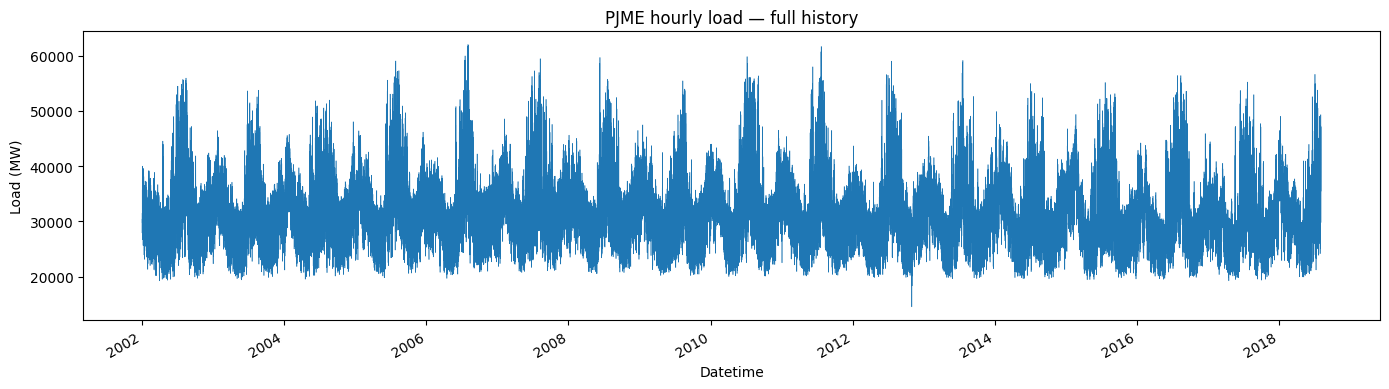

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
df['PJME_MW'].plot(ax=ax, linewidth=0.4)
ax.set_title('PJME hourly load — full history')
ax.set_ylabel('Load (MW)')
fig.tight_layout()
fig.savefig(FIGS / 'eda_full_series.png', dpi=120)
plt.show()

## Seasonality at three scales

Strong patterns at hour-of-day, day-of-week, and month justify a SARIMA model over a plain ARIMA.

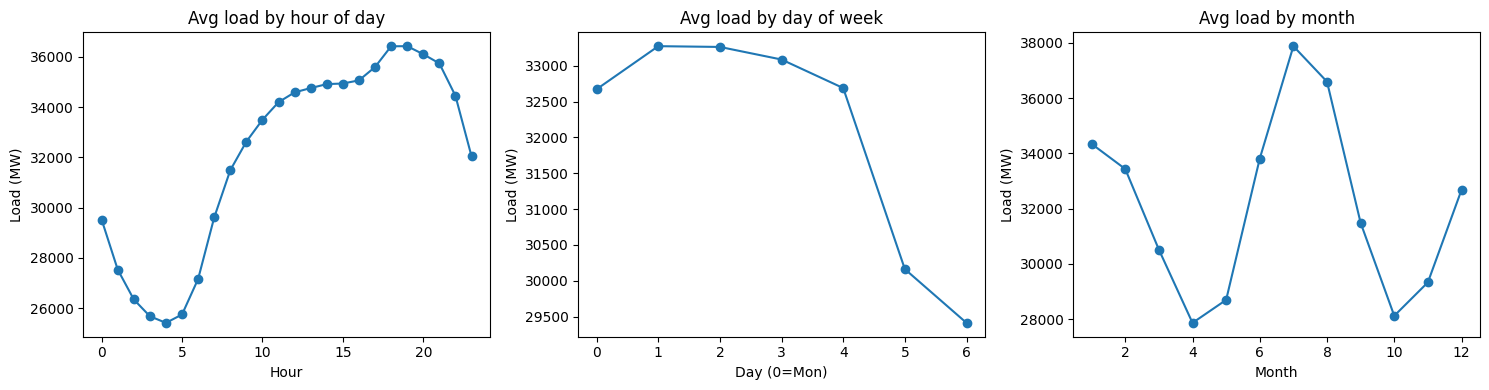

In [4]:
by_hour = df.groupby(df.index.hour)['PJME_MW'].mean()
by_dow = df.groupby(df.index.dayofweek)['PJME_MW'].mean()
by_month = df.groupby(df.index.month)['PJME_MW'].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
by_hour.plot(ax=axes[0], marker='o'); axes[0].set_title('Avg load by hour of day'); axes[0].set_xlabel('Hour')
by_dow.plot(ax=axes[1], marker='o'); axes[1].set_title('Avg load by day of week'); axes[1].set_xlabel('Day (0=Mon)')
by_month.plot(ax=axes[2], marker='o'); axes[2].set_title('Avg load by month'); axes[2].set_xlabel('Month')
for ax in axes:
    ax.set_ylabel('Load (MW)')
fig.tight_layout()
fig.savefig(FIGS / 'eda_seasonality.png', dpi=120)
plt.show()

## Decomposition (period = 24)

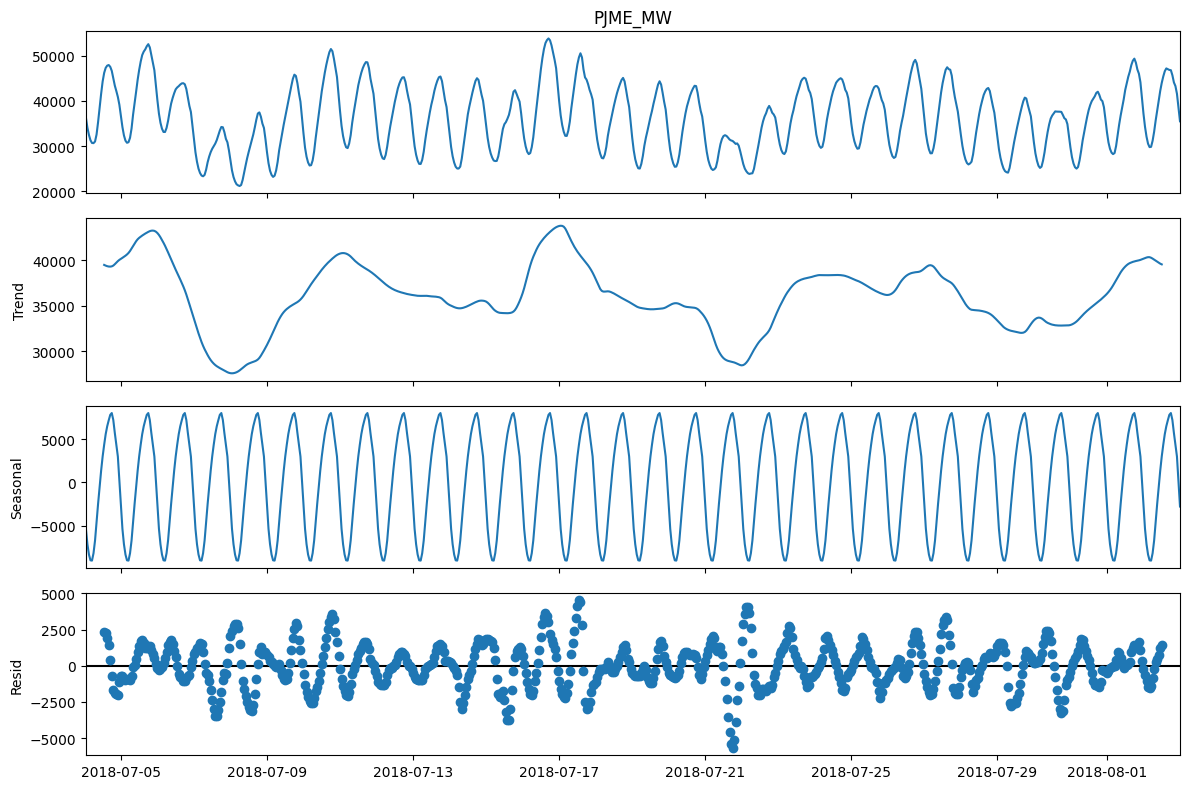

In [5]:
sample = df['PJME_MW'].iloc[-24*30:]
decomp = seasonal_decompose(sample, period=24, model='additive')
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.tight_layout()
fig.savefig(FIGS / 'eda_decomposition.png', dpi=120)
plt.show()

## Stationarity — ADF test

Null hypothesis: the series has a unit root (non-stationary). p < 0.05 means we reject it.

In [6]:
def adf_report(label, series):
    series = series.dropna()
    stat, pvalue, *_ = adfuller(series.iloc[-24*30*6:])  # tail 6 months for tractable runtime
    print(f'{label:30s}  stat={stat:8.3f}  p={pvalue:.4g}')

adf_report('raw', df['PJME_MW'])
adf_report('first difference', df['PJME_MW'].diff())
adf_report('seasonal (lag 24) difference', df['PJME_MW'].diff(24))

raw                             stat=  -5.876  p=3.159e-07
first difference                stat= -11.886  p=6.027e-22
seasonal (lag 24) difference    stat= -11.866  p=6.659e-22


## ACF / PACF

We expect a strong lag-24 spike — that is the daily seasonal signature SARIMA captures via the seasonal AR/MA terms.

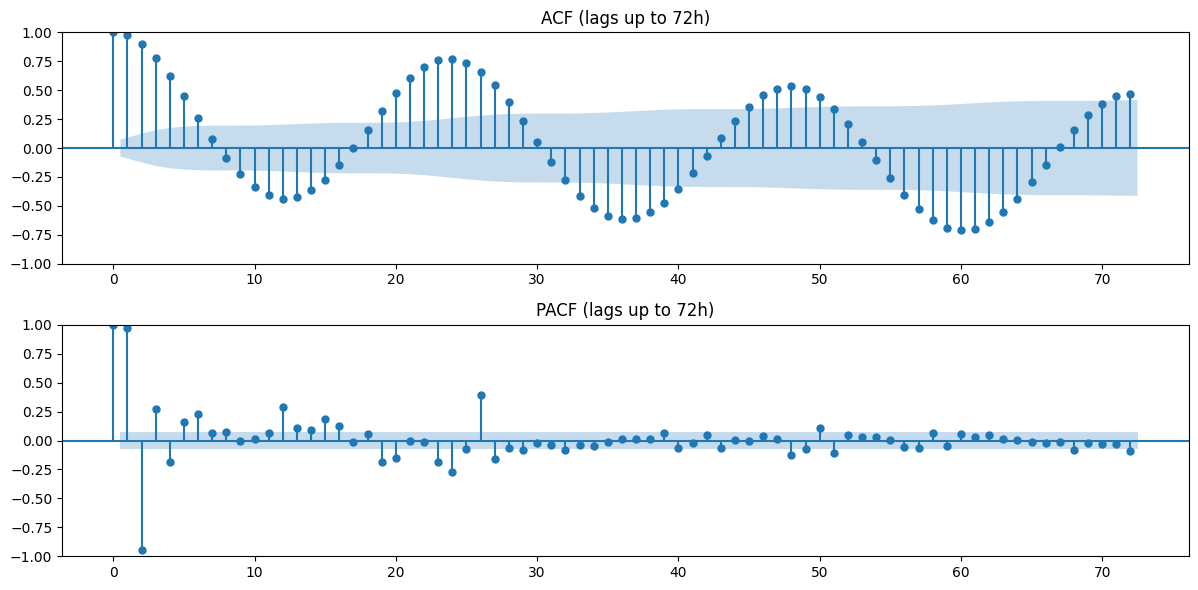

In [7]:
tail = df['PJME_MW'].iloc[-24*30:]  # last 30 days, lighter to plot
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(tail.dropna(), lags=72, ax=axes[0])
axes[0].set_title('ACF (lags up to 72h)')
plot_pacf(tail.dropna(), lags=72, ax=axes[1], method='ywm')
axes[1].set_title('PACF (lags up to 72h)')
fig.tight_layout()
fig.savefig(FIGS / 'eda_acf_pacf.png', dpi=120)
plt.show()